In [64]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [39]:
image_paths = glob.glob(
    r"C:\Users\anaga\ImageClassifierAGSR\data\raw\train\*\*.jpg"
)

In [40]:
# Separar imágenes de perros y gatos
dog_images = [path for path in image_paths if 'dog' in path.lower()]
cat_images = [path for path in image_paths if 'cat' in path.lower()]

print(f"Total de imágenes de perros: {len(dog_images)}")
print(f"Total de imágenes de gatos: {len(cat_images)}")

Total de imágenes de perros: 12500
Total de imágenes de gatos: 12500


In [ ]:
# Seleccionamos 9 imágenes de cada categoría
dogs_sample = dog_images[:9]
cats_sample = cat_images[:9]

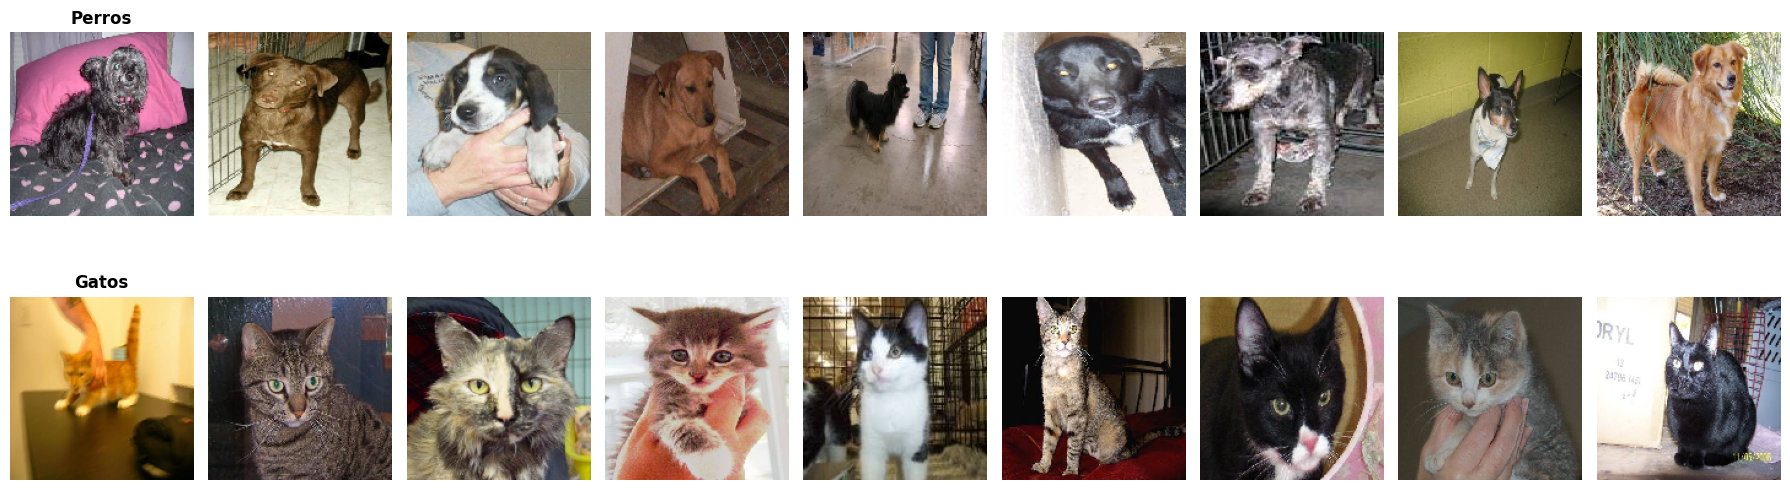

In [42]:
# Crear figura con subcuadrículas: 2 filas x 9 columnas
fig, axes = plt.subplots(2, 9, figsize=(18, 6))

# Fila 1: Perros
for i, img_path in enumerate(dogs_sample):
    img = image.load_img(img_path, target_size=(150, 150))
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Perros', fontsize=12, fontweight='bold')

# Fila 2: Gatos
for i, img_path in enumerate(cats_sample):
    img = image.load_img(img_path, target_size=(150, 150))
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Gatos', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [43]:
# Convertir imagen a array (matriz de números)
img_array = image.img_to_array(img)
print(f"Forma del array: {img_array.shape}")  # (alto, ancho, canales de color)
print(f"Rango de valores: {img_array.min()} a {img_array.max()}") # Los colores se forman mezclando 3 colores básicos: Rojo (R), Verde (G), Azul (B). Cada color tiene un valor de 0 a 255

# Ejemplo: ver los primeros valores
print(f"\nPrimeros valores del pixel superior izquierdo:")
print(img_array[0, 0])  # RGB: [Rojo, Verde, Azul]

Forma del array: (150, 150, 3)
Rango de valores: 0.0 a 255.0

Primeros valores del pixel superior izquierdo:
[247. 240. 212.]


In [44]:
# Definir tamaño estándar para todas las imágenes
IMG_SIZE = (150, 150)  # Todas las imágenes tendrán 150x150 pixels (debe coincidir con el modelo)

# Listas para guardar imágenes y etiquetas
images = []
labels = []

# IMPORTANTE: Usar solo un subconjunto de imágenes para no quedarse sin memoria
MAX_IMAGES = 25000  # Procesar solo 25000 imágenes.

print(f"Cargando máximo {MAX_IMAGES} imágenes...")
for i, img_path in enumerate(image_paths[:MAX_IMAGES]):
    
    # Cargar imagen con el tamaño definido
    img = image.load_img(img_path, target_size=IMG_SIZE)
    
    # Convertir a array
    img_array = image.img_to_array(img)
    
    # Normalizar: convertir valores de 0-255 a 0-1
    img_array = img_array / 255.0
    
    # Guardar
    images.append(img_array)
    
    # Extraer etiqueta del nombre del archivo
    # Ejemplo: si el archivo se llama "gato_001.jpg", la etiqueta sería "gato"
    label = os.path.basename(img_path).split('.')[0]
    labels.append(label)
    
    if (i + 1) % 200 == 0:
        print(f"Procesadas {i + 1} imágenes...")

print(f"\n✓ Total de imágenes procesadas: {len(images)}")
print(f"✓ Total de etiquetas: {len(labels)}")
print(f"✓ Categorías únicas: {set(labels)}")

Cargando máximo 25000 imágenes...
Procesadas 200 imágenes...
Procesadas 400 imágenes...
Procesadas 600 imágenes...
Procesadas 800 imágenes...
Procesadas 1000 imágenes...
Procesadas 1200 imágenes...
Procesadas 1400 imágenes...
Procesadas 1600 imágenes...
Procesadas 1800 imágenes...
Procesadas 2000 imágenes...
Procesadas 2200 imágenes...
Procesadas 2400 imágenes...
Procesadas 2600 imágenes...
Procesadas 2800 imágenes...
Procesadas 3000 imágenes...
Procesadas 3200 imágenes...
Procesadas 3400 imágenes...
Procesadas 3600 imágenes...
Procesadas 3800 imágenes...
Procesadas 4000 imágenes...
Procesadas 4200 imágenes...
Procesadas 4400 imágenes...
Procesadas 4600 imágenes...
Procesadas 4800 imágenes...
Procesadas 5000 imágenes...
Procesadas 5200 imágenes...
Procesadas 5400 imágenes...
Procesadas 5600 imágenes...
Procesadas 5800 imágenes...
Procesadas 6000 imágenes...
Procesadas 6200 imágenes...
Procesadas 6400 imágenes...
Procesadas 6600 imágenes...
Procesadas 6800 imágenes...
Procesadas 7000 im

In [45]:
# Convertir listas a arrays de NumPy
X = np.array(images)  # X = datos (imágenes)
print(f"Forma de X: {X.shape}")  # (num_imágenes, alto, ancho, canales)

# Convertir etiquetas de texto a números
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)  # y = etiquetas (0, 1)
print(f"Forma de y: {y.shape}")
print(f"\nEjemplo de conversión:")
print(f"  {labels[0]} → {y[0]}")
print(f"  {labels[12501]} → {y[12501]}")

Forma de X: (25000, 150, 150, 3)
Forma de y: (25000,)

Ejemplo de conversión:
  cat → 0
  dog → 1


In [46]:
# 1. Ver las primeras 5 y últimas 5 etiquetas
print("Primeras 5 etiquetas:")
for i in range(min(5, len(labels))):
    print(f"  {i}: {labels[i]}")

print("\nÚltimas 5 etiquetas:")
for i in range(max(0, len(labels) - 5), len(labels)):
    print(f"  {i}: {labels[i]}")

# 2. Contar cuántas imágenes hay de cada categoría
from collections import Counter
conteo = Counter(labels)
print(f"\n📊 Conteo por categoría:")
for categoria, cantidad in conteo.items():
    print(f"  {categoria}: {cantidad} imágenes")

# 3. Ver qué categorías únicas existen
print(f"\n🏷️ Categorías únicas encontradas: {sorted(set(labels))}")

# 4. Verificar algunas rutas y sus etiquetas
print(f"\n🔍 Verificación ruta → etiqueta (primeras 4):")
for i in range(min(4, len(image_paths))):
    filename = os.path.basename(image_paths[i])
    print(f"  {i}: {filename} → '{labels[i]}'")

# Verificar posiciones 12501-12504
print(f"\n🔍 Verificación ruta → etiqueta (desde 12501 hasta 12504):")
for i in range(12501, min(12505, len(image_paths))):
    if i < len(image_paths):
        filename = os.path.basename(image_paths[i])
        print(f"  {i}: {filename} → '{labels[i]}'")

Primeras 5 etiquetas:
  0: cat
  1: cat
  2: cat
  3: cat
  4: cat

Últimas 5 etiquetas:
  24995: dog
  24996: dog
  24997: dog
  24998: dog
  24999: dog

📊 Conteo por categoría:
  cat: 12500 imágenes
  dog: 12500 imágenes

🏷️ Categorías únicas encontradas: ['cat', 'dog']

🔍 Verificación ruta → etiqueta (primeras 4):
  0: cat.0.jpg → 'cat'
  1: cat.1.jpg → 'cat'
  2: cat.10.jpg → 'cat'
  3: cat.100.jpg → 'cat'

🔍 Verificación ruta → etiqueta (desde 12501 hasta 12504):
  12501: dog.1.jpg → 'dog'
  12502: dog.10.jpg → 'dog'
  12503: dog.100.jpg → 'dog'
  12504: dog.1000.jpg → 'dog'


In [47]:
from sklearn.model_selection import train_test_split

# Dividir datos: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% para pruebas
    random_state=0  
)

print(f"Datos de entrenamiento: {X_train.shape[0]} imágenes")
print(f"Datos de prueba: {X_test.shape[0]} imágenes")

Datos de entrenamiento: 20000 imágenes
Datos de prueba: 5000 imágenes


In [48]:
# MODELO PARA 25,000 IMÁGENES

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Bloque 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    
    # Bloque 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Bloque 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Bloque 4
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Clasificador
    Flatten(),
    Dropout(0.5),  # Reduce overfitting
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.summary()

c:\Users\anaga\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,812,482 (25.99 MB)

 Trainable params: 6,812,482 (25.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilar modelo
model.compile(
    optimizer='adam',  # Algoritmo para ajustar pesos
    loss='sparse_categorical_crossentropy',  # Función de error
    metrics=['accuracy']  # Métrica para evaluar
)

✓ Modelo compilado y listo para entrenar


In [ ]:

X_train_2, X_val, y_train_2, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=0  # 0.20 * 0.8 = 0.2 del total
)
print(f"Datos de entrenamiento finales: {X_train_2.shape[0]} imágenes")
print(f"Datos de validación: {X_val.shape[0]} imágenes")

Datos de entrenamiento finales: 16000 imágenes
Datos de validación: 4000 imágenes


In [51]:
# Entrenar el modelo
history = model.fit(
    X_train_2, y_train_2,  # Datos de entrenamiento
    epochs=2,  # Número de veces que verá todos los datos
    validation_data=(X_val, y_val),  # Datos para  varlidar validation_split = 0.2
    verbose=1  # Mostrar progreso
)

print("\n✓ Entrenamiento completado")

Epoch 1/2
500/500 ━━━━━━━━━━━━━━━━━━━━ 86s 168ms/step - accuracy: 0.5312 - loss: 0.6905 - val_accuracy: 0.5617 - val_loss: 0.6829
Epoch 2/2
500/500 ━━━━━━━━━━━━━━━━━━━━ 97s 193ms/step - accuracy: 0.6341 - loss: 0.6400 - val_accuracy: 0.7253 - val_loss: 0.5553

✓ Entrenamiento completado


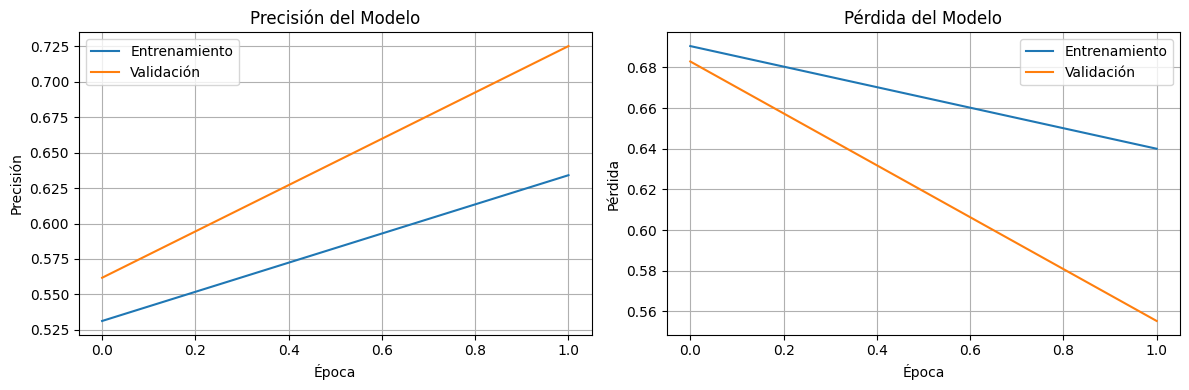

In [52]:
# Visualizar aprendizaje
#  Graficar la precisión
plt.figure(figsize=(12, 4))

# Gráfica 1: Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Gráfica 2: Pérdida (error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Durante las primeras épocas, tanto la precisión como la pérdida mejoran de forma consistente en entrenamiento y validación. No se observa overfitting, ya que la pérdida de validación continúa disminuyendo y la precisión de validación incluso supera a la de entrenamiento, lo que indica buena capacidad de generalización en esta fase inicial.

In [53]:
# Evaluacion de modelo

# Evaluar en datos de prueba
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"📊 Resultados en datos de prueba:")
print(f"   Precisión: {test_accuracy * 100:.2f}%")
print(f"   Pérdida: {test_loss:.4f}")

📊 Resultados en datos de prueba:
   Precisión: 71.22%
   Pérdida: 0.5602


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


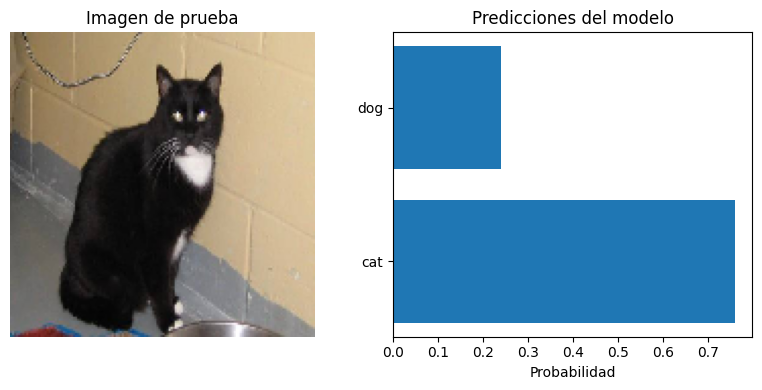

Predicción:
   Clase real: cat
   Clase predicha: cat
   Confianza: 76.08%


In [57]:
8# Seleccionar una imagen de prueba
test_index = 8
test_image = X_test[test_index]
true_label = y_test[test_index]

# Hacer predicción (necesita dimensión extra)
prediction = model.predict(test_image.reshape(1, 150, 150, 3))
predicted_class = np.argmax(prediction)  # Clase con mayor probabilidad

# Visualizar resultado
plt.figure(figsize=(8, 4))

# Imagen
plt.subplot(1, 2, 1)
plt.imshow(test_image)
plt.title(f"Imagen de prueba")
plt.axis('off')

# Probabilidades
plt.subplot(1, 2, 2)
classes = label_encoder.classes_
plt.barh(classes, prediction[0])
plt.xlabel('Probabilidad')
plt.title('Predicciones del modelo')
plt.tight_layout()
plt.show()

# Resultado
print(f"Predicción:")
print(f"   Clase real: {label_encoder.inverse_transform([true_label])[0]}")
print(f"   Clase predicha: {label_encoder.inverse_transform([predicted_class])[0]}")
print(f"   Confianza: {prediction[0][predicted_class] * 100:.2f}%")

In [59]:
#Optimizacion de modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l2

best_model = Sequential ([
    # Bloque 1
    Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(0.001), input_shape=(150,150,3)),
    BatchNormalization(), # Una capa que normaliza los valores dentro de la red para que no se “descontrolen”
    LeakyReLU(), # Una versión mejorada de ReLU que evita que las neuronas “mueran”.
    MaxPooling2D(2,2),

    # Bloque 2
    Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(2,2),

    # Bloque 3
    Conv2D(128, (3,3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(2,2),

    # Bloque 4
    Conv2D(256, (3,3), padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(2,2),

    Flatten(),

    # Clasificador
    Dense(256, kernel_regularizer=l2(0.001)),  # Una técnica de regularización que penaliza pesos demasiado grandes.
    BatchNormalization(),
    LeakyReLU(),
    Dropout(0.4), # 0.5 es un valor muy alto para una CNN profunda.

    Dense(2, activation='softmax')
])

c:\Users\anaga\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
from tensorflow.keras.optimizers import Adam 

best_model.compile(
    optimizer=Adam(learning_rate=0.0005), # Las CNN profundas aprenden mejor con un paso más pequeño.
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
    )

In [61]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint 

callbacks = [ EarlyStopping(patience=5, restore_best_weights=True), #  Detiene el entrenamiento cuando ya no mejora.
             ReduceLROnPlateau(factor=0.2, patience=3), # Baja el learning rate cuando el modelo se estanca. 
             ModelCheckpoint("mejor_modelo.h5", save_best_only=True) ] # Guarda el mejor modelo durante el entrenamiento.

In [63]:
history_2 = best_model.fit(
    X_train_2, y_train_2,
    epochs=5,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.7685 - loss: 0.9174

500/500 ━━━━━━━━━━━━━━━━━━━━ 154s 307ms/step - accuracy: 0.7782 - loss: 0.8527 - val_accuracy: 0.7682 - val_loss: 0.7663 - learning_rate: 5.0000e-04
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.8060 - loss: 0.6961

500/500 ━━━━━━━━━━━━━━━━━━━━ 151s 301ms/step - accuracy: 0.8076 - loss: 0.6750 - val_accuracy: 0.7343 - val_loss: 0.7505 - learning_rate: 5.0000e-04
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 151s 301ms/step - accuracy: 0.8270 - loss: 0.5861 - val_accuracy: 0.5635 - val_loss: 1.1197 - learning_rate: 5.0000e-04
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.8513 - loss: 0.5269

500/500 ━━━━━━━━━━━━━━━━━━━━ 151s 303ms/step - accuracy: 0.8469 - loss: 0.5306 - val_accuracy: 0.8263 - val_loss: 0.5818 - learning_rate: 5.0000e-04
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 153s 306ms/step - accuracy: 0.8574 - loss: 0.5051 - val_accuracy: 0.8065 - val_loss: 0.6259 - learning_rate: 5.0000e-04


In [65]:
df = pd.DataFrame(history_2.history) 
print(df)

   accuracy      loss  val_accuracy  val_loss  learning_rate
0  0.778188  0.852674       0.76825  0.766254         0.0005
1  0.807625  0.674973       0.73425  0.750473         0.0005
2  0.827000  0.586090       0.56350  1.119725         0.0005
3  0.846937  0.530605       0.82625  0.581813         0.0005
4  0.857437  0.505083       0.80650  0.625851         0.0005


Durante el entrenamiento se observa una mejora progresiva en la precisión de entrenamiento. La validación presenta oscilaciones, con un claro episodio de overfitting en la época 2. La mejor generalización se alcanza en la época 3, donde la precisión de validación es máxima y la pérdida se mantiene baja, por lo que ese punto se considera óptimo.

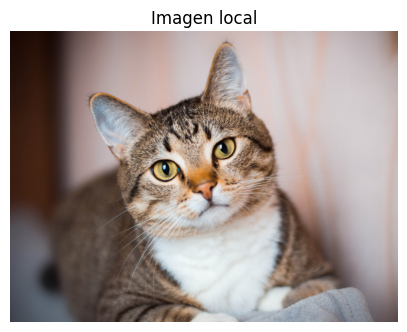

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step

🎯 Predicción: cat
   Confianza: 99.45%


In [67]:
# 1. Cargar el modelo
modelo = load_model("mejor_modelo.h5")

# 2. Cargar imagen local
img_local_1 = image.load_img(
    r"C:\Users\anaga\Downloads\gatocomuneuropeo-97.jpg")

# 3. Mostrar imagen original
plt.figure(figsize=(5, 5))
plt.imshow(img_local_1)
plt.axis("off")
plt.title("Imagen local")
plt.show()

# 4. REDIMENSIONAR AL TAMAÑO DEL MODELO
img_resized = img_local_1.resize((150, 150))

# 5. Convertir a array y normalizar
img_array = image.img_to_array(img_resized)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 6. Predicción
prediction = modelo.predict(img_array)
predicted_class = np.argmax(prediction)

print("\n🎯 Predicción:", label_encoder.inverse_transform([predicted_class])[0])
print("   Confianza:", f"{prediction[0][predicted_class] * 100:.2f}%")
